In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):
    
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

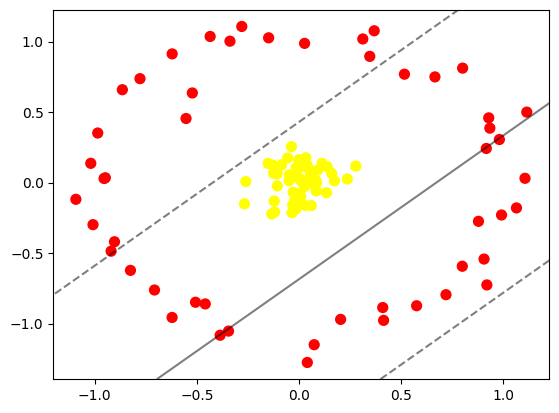

In [5]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [6]:
r = np.exp(-(X**2).sum(1))

In [ ]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-6.20718625e-01,  9.12505126e-01],
       [ 3.12647083e-01,  1.01838471e+00],
       [-1.05784821e-01, -2.35749946e-02],
       [ 7.99697034e-01, -5.93133854e-01],
       [ 4.14482294e-01, -9.76904317e-01],
       [-3.44779988e-01, -1.05296464e+00],
       [-1.54910288e-02, -1.87150225e-01],
       [ 4.15445235e-02,  1.06154629e-01],
       [-3.37783930e-01,  1.00268936e+00],
       [-4.70658408e-02,  5.42716759e-02],
       [ 5.44606849e-02,  4.35966541e-02],
       [-6.21066760e-01, -9.56401114e-01],
       [ 2.78489530e-01,  1.16796427e-01],
       [-1.24172435e-01,  6.73530369e-02],
       [-3.35522265e-02, -2.13426789e-01],
       [-1.21255535e-01, -1.31039644e-01],
       [ 3.32672619e-02,  1.76198702e-01],
       [ 1.11556834e+00,  4.99723359e-01],
       [-1.25829586e-01,  1.23188824e-01],
       [-5.06346538e-01, -8.48447373e-01],
       [-3.91840050e-03,  9.87677904e-02],
       [ 3.46769118e-01,  8.95033141e-01],
       

In [10]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

[[ 0.51637287  0.76854226]
 [-0.903091   -0.41955897]
 [-0.55279605  0.45442373]
 [ 0.87892004 -0.27465962]
 [-0.45883137 -0.8604118 ]
 [ 0.91729962  0.24199195]
 [ 0.41025385 -0.88599366]
 [ 0.27848953  0.11679643]
 [-0.03692624  0.25478645]
 [-0.2666599  -0.15051651]]


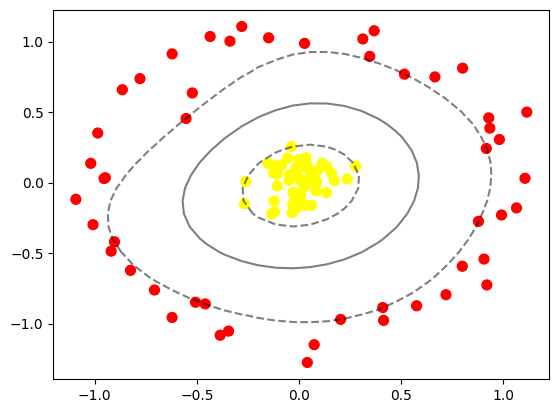

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')

print(clf.support_vectors_)

In [19]:
# Test predict

print(clf.predict([[0, 0]]))
print(clf.predict([[0.1, 0.2]]))
print(clf.predict([[1, 0]]))
print(clf.predict([[0, 1]]))
print(clf.predict([[-1, 0]]))

[1]
[1]
[0]
[0]
[0]
